# Finance Forecaster Notebook

This version keeps outputs in notebook variables and displays plots inline instead of saving files to folders.


## Imports


In [2]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 35.2 MB/s eta 0:00:00


In [3]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from IPython.display import display
from arch import arch_model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential


## Parameters


In [4]:
ticker = 'QQQ'
start = '2015-01-01'
end = '2025-01-01'
ticker = ticker.upper()


## Data download helpers


In [5]:
def download_stock_data(ticker: str, start_date: str, end_date: str) -> pd.DataFrame:
    data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f'No data found for ticker: {ticker}')

    if isinstance(data.columns, pd.MultiIndex):
        price = data['Close']
        volume = data['Volume']
        if isinstance(price, pd.DataFrame):
            price = price.iloc[:, 0]
        if isinstance(volume, pd.DataFrame):
            volume = volume.iloc[:, 0]
    else:
        price = data['Close']
        volume = data['Volume']

    df = pd.DataFrame({'price': price, 'volume': volume})
    df.dropna(inplace=True)
    return df


def download_external_market_features(start_date: str, end_date: str) -> pd.DataFrame:
    tickers = {
        'vix': '^VIX', 'spy': 'SPY', 'iwm': 'IWM', 'xlk': 'XLK', 'xlf': 'XLF',
        'xli': 'XLI', 'xly': 'XLY', 'xlp': 'XLP', 'tlt': 'TLT', 'hyg': 'HYG',
        'uup': 'UUP', 'gld': 'GLD', 'tnx': '^TNX',
    }
    feature_data = pd.DataFrame()

    for name, ticker_symbol in tickers.items():
        data = yf.download(ticker_symbol, start=start_date, end=end_date, auto_adjust=True, progress=False)
        if data.empty:
            print(f'Warning: No data found for {ticker_symbol}')
            continue

        if isinstance(data.columns, pd.MultiIndex):
            close = data['Close']
            if isinstance(close, pd.DataFrame):
                close = close.iloc[:, 0]
        else:
            close = data['Close']

        feature_data[f'{name}_close'] = close
        feature_data[f'{name}_return'] = np.log(close).diff()

    feature_data.dropna(inplace=True)
    feature_data['iwm_spy_relative_strength'] = feature_data['iwm_close'] / feature_data['spy_close']
    feature_data['qqq_spy_market_strength'] = feature_data['xlk_close'] / feature_data['spy_close']
    feature_data['tech_vs_staples'] = feature_data['xlk_close'] / feature_data['xlp_close']
    feature_data['discretionary_vs_staples'] = feature_data['xly_close'] / feature_data['xlp_close']
    feature_data['financials_vs_market'] = feature_data['xlf_close'] / feature_data['spy_close']
    feature_data['industrials_vs_market'] = feature_data['xli_close'] / feature_data['spy_close']
    feature_data['credit_risk_appetite'] = feature_data['hyg_close'] / feature_data['tlt_close']
    feature_data['gold_vs_market'] = feature_data['gld_close'] / feature_data['spy_close']
    return feature_data


## Feature and test helpers


In [6]:
def add_log_returns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['log_price'] = np.log(df['price'])
    df['log_return'] = df['log_price'].diff()
    df['log_return_squared'] = df['log_return'] ** 2
    return df


def run_adf_test(series: pd.Series, series_name: str) -> dict:
    result = adfuller(series.dropna())
    return {
        'series': series_name,
        'test': 'ADF',
        'statistic': result[0],
        'p_value': result[1],
        'lags_used': result[2],
        'observations': result[3],
        'stationary_result': 'Stationary' if result[1] <= 0.05 else 'Non-stationary',
    }


def run_kpss_test(series: pd.Series, series_name: str) -> dict:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', InterpolationWarning)
        statistic, p_value, lags, critical_values = kpss(series.dropna(), regression='c', nlags='auto')
    return {
        'series': series_name,
        'test': 'KPSS',
        'statistic': statistic,
        'p_value': p_value,
        'lags_used': lags,
        'observations': len(series.dropna()),
        'stationary_result': 'Non-stationary' if p_value <= 0.05 else 'Stationary',
    }


## Inline plotting helpers


In [7]:
def plot_time_series(df: pd.DataFrame, column: str, title: str, y_label: str):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df[column])
    ax.set_title(title)
    ax.set_xlabel('Date')
    ax.set_ylabel(y_label)
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_acf_inline(series: pd.Series, title: str, lags: int = 40):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_acf(series.dropna(), lags=lags, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_pacf_inline(series: pd.Series, title: str, lags: int = 40):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_pacf(series.dropna(), lags=lags, method='ywm', ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_garch_volatility(df: pd.DataFrame, ticker: str):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df.index, df['garch_conditional_volatility'])
    ax.set_title(f'{ticker} GARCH(1,1) Conditional Volatility')
    ax.set_xlabel('Date')
    ax.set_ylabel('Conditional Volatility (%)')
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax


def plot_training_history(history_df: pd.DataFrame, ticker: str):
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(history_df['loss'], label='Train Loss')
    ax1.plot(history_df['val_loss'], label='Validation Loss')
    ax1.set_title(f'{ticker} LSTM + GARCH Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    plt.tight_layout()
    plt.show()

    fig2 = None
    if 'accuracy' in history_df.columns and 'val_accuracy' in history_df.columns:
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        ax2.plot(history_df['accuracy'], label='Train Accuracy')
        ax2.plot(history_df['val_accuracy'], label='Validation Accuracy')
        ax2.set_title(f'{ticker} LSTM + GARCH Training Accuracy')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy')
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
        plt.show()
    return fig1, fig2


def plot_equity_curve(backtest_df: pd.DataFrame, ticker: str):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(backtest_df['date'], backtest_df['strategy_equity'], label='Regime-Aware Strategy')
    ax.plot(backtest_df['date'], backtest_df['buy_hold_equity'], label='Buy and Hold')
    ax.set_title(f'{ticker} Regime-Aware Backtest Equity Curve')
    ax.set_xlabel('Date')
    ax.set_ylabel('Growth of $1')
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()
    return fig, ax


## GARCH and regime helpers


In [8]:
def compute_expanding_garch_volatility(returns: pd.Series, min_window: int = 500) -> pd.Series:
    print('Computing expanding-window GARCH volatility...')
    returns_pct = returns.dropna() * 100
    conditional_vol = pd.Series(index=returns_pct.index, dtype=float, name='garch_conditional_volatility')

    for i in range(min_window, len(returns_pct)):
        window_returns = returns_pct.iloc[: i + 1]
        try:
            am = arch_model(window_returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=True)
            res = am.fit(disp='off', show_warning=False)
            conditional_vol.iloc[i] = res.conditional_volatility.iloc[-1]
        except Exception:
            conditional_vol.iloc[i] = (
                conditional_vol.iloc[i - 1]
                if i > 0 and not pd.isna(conditional_vol.iloc[i - 1])
                else window_returns.std()
            )
    print('Expanding GARCH volatility computed.')
    return conditional_vol


def fit_garch_model(df: pd.DataFrame, min_window: int = 500):
    df = df.copy()
    df['garch_conditional_volatility'] = compute_expanding_garch_volatility(df['log_return'], min_window=min_window)
    df['garch_volatility_change'] = df['garch_conditional_volatility'].diff()
    df['garch_volatility_lag_1'] = df['garch_conditional_volatility'].shift(1)
    df['garch_volatility_lag_2'] = df['garch_conditional_volatility'].shift(2)

    garch_summary_text = None
    try:
        recent_returns = (df['log_return'].dropna() * 100).iloc[-800:]
        final_model = arch_model(recent_returns, mean='Constant', vol='GARCH', p=1, q=1, dist='normal', rescale=True)
        results = final_model.fit(disp='off')
        garch_summary_text = str(results.summary())
        print(garch_summary_text)
    except Exception as e:
        print(f'Could not compute final GARCH summary: {e}')

    return df, garch_summary_text


def add_market_regimes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    vol_series = df['garch_conditional_volatility'].dropna()
    expanding_vol_cutoff = vol_series.expanding(min_periods=252).quantile(0.75)
    df['vol_cutoff'] = expanding_vol_cutoff.reindex(df.index, method='ffill')
    df['volatility_regime'] = np.where(df['garch_conditional_volatility'] > df['vol_cutoff'], 'high_vol', 'low_vol')

    if 'vix_close' in df.columns:
        df['vix_regime'] = np.where(df['vix_close'] > 25, 'high_vix', 'normal_vix')
    else:
        df['vix_regime'] = 'unknown_vix'

    df['sma_20'] = df['price'].rolling(20).mean()
    df['sma_50'] = df['price'].rolling(50).mean()
    df['trend_regime'] = np.where(df['sma_20'] > df['sma_50'], 'uptrend', 'downtrend')

    conditions = [
        (df['volatility_regime'] == 'high_vol') | (df['vix_regime'] == 'high_vix'),
        (df['volatility_regime'] == 'low_vol') & (df['trend_regime'] == 'uptrend'),
        (df['volatility_regime'] == 'low_vol') & (df['trend_regime'] == 'downtrend'),
    ]
    choices = ['risk_off', 'low_vol_uptrend', 'low_vol_downtrend']
    df['market_regime'] = np.select(conditions, choices, default='neutral')
    return df


## LSTM helpers


In [9]:
def add_lstm_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['return_lag_1'] = df['log_return'].shift(1)
    df['return_lag_2'] = df['log_return'].shift(2)
    df['return_lag_3'] = df['log_return'].shift(3)
    df['return_lag_5'] = df['log_return'].shift(5)
    df['momentum_3'] = df['log_return'].rolling(3).sum()
    df['momentum_5'] = df['log_return'].rolling(5).sum()
    df['momentum_10'] = df['log_return'].rolling(10).sum()
    df['rolling_mean_5'] = df['log_return'].rolling(5).mean()
    df['rolling_std_5'] = df['log_return'].rolling(5).std()
    df['rolling_mean_20'] = df['log_return'].rolling(20).mean()
    df['rolling_std_20'] = df['log_return'].rolling(20).std()
    df['volatility_ratio'] = df['rolling_std_5'] / df['rolling_std_20']
    df['volume_momentum_5'] = df['volume'].rolling(5).mean() if 'volume' in df.columns else 0
    df['vix_change'] = df['vix_close'].diff()
    df['vix_lag_1'] = df['vix_close'].shift(1)
    df['spy_momentum_5'] = df['spy_return'].rolling(5).sum()
    df['iwm_momentum_5'] = df['iwm_return'].rolling(5).sum()
    df['xlk_momentum_5'] = df['xlk_return'].rolling(5).sum()
    df['rate_change'] = df['tnx_close'].diff()
    df['dollar_momentum_5'] = df['uup_return'].rolling(5).sum()
    df['bond_momentum_5'] = df['tlt_return'].rolling(5).sum()
    df['credit_momentum_5'] = df['hyg_return'].rolling(5).sum()
    df['target'] = (df['log_return'].shift(-1) > 0).astype(int)
    return df


def create_lstm_dataset(df: pd.DataFrame, lookback: int = 30):
    model_df = add_lstm_features(df)
    feature_cols = [
        'log_return', 'log_return_squared', 'garch_conditional_volatility', 'garch_volatility_change',
        'garch_volatility_lag_1', 'garch_volatility_lag_2', 'return_lag_1', 'return_lag_2', 'return_lag_3',
        'return_lag_5', 'momentum_3', 'momentum_5', 'momentum_10', 'rolling_mean_5', 'rolling_std_5',
        'rolling_mean_20', 'rolling_std_20', 'volatility_ratio', 'vix_close', 'vix_return', 'vix_change',
        'vix_lag_1', 'spy_return', 'spy_momentum_5', 'iwm_return', 'iwm_momentum_5', 'iwm_spy_relative_strength',
        'credit_risk_appetite', 'xlk_return', 'xlk_momentum_5', 'qqq_spy_market_strength', 'tech_vs_staples',
        'discretionary_vs_staples', 'financials_vs_market', 'industrials_vs_market', 'tnx_close', 'rate_change',
        'uup_return', 'dollar_momentum_5', 'tlt_return', 'bond_momentum_5', 'hyg_return', 'credit_momentum_5',
        'gld_return', 'gold_vs_market',
    ]

    model_df.dropna(inplace=True)
    features = model_df[feature_cols].values
    target = model_df['target'].values
    dates = model_df.index

    split_index = int(len(features) * 0.8)
    scaler = StandardScaler()
    features_train_scaled = scaler.fit_transform(features[:split_index])
    features_test_scaled = scaler.transform(features[split_index:])
    features_scaled = np.vstack([features_train_scaled, features_test_scaled])

    X, y, sequence_dates = [], [], []
    for i in range(lookback, len(features_scaled)):
        X.append(features_scaled[i - lookback:i])
        y.append(target[i])
        sequence_dates.append(dates[i])

    X = np.array(X)
    y = np.array(y)
    sequence_dates = np.array(sequence_dates)
    train_sequence_count = split_index - lookback

    X_train = X[:train_sequence_count]
    X_test = X[train_sequence_count:]
    y_train = y[:train_sequence_count]
    y_test = y[train_sequence_count:]
    test_dates = sequence_dates[train_sequence_count:]
    return X_train, X_test, y_train, y_test, test_dates, scaler, feature_cols, model_df


def train_lstm_garch_model(df: pd.DataFrame, ticker: str, lookback: int = 30, epochs: int = 100, batch_size: int = 32, prediction_threshold: float = 0.55):
    X_train, X_test, y_train, y_test, test_dates, scaler, feature_cols, model_df = create_lstm_dataset(df, lookback=lookback)
    classes = np.unique(y_train)
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
    class_weights = dict(zip(classes, weights))

    model = Sequential()
    model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.30))
    model.add(LSTM(units=32))
    model.add(Dropout(0.30))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=1,
    )

    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (y_pred_prob >= prediction_threshold).astype(int)
    accuracy = accuracy_score(y_test, y_pred)
    majority_class = int(pd.Series(y_train).mode()[0])
    baseline_pred = np.full_like(y_test, majority_class)
    baseline_accuracy = accuracy_score(y_test, baseline_pred)

    try:
        roc_auc = roc_auc_score(y_test, y_pred_prob)
    except ValueError:
        roc_auc = np.nan

    report = classification_report(y_test, y_pred, zero_division=0)
    matrix = confusion_matrix(y_test, y_pred)
    metrics_summary = {
        'accuracy': accuracy,
        'baseline_accuracy': baseline_accuracy,
        'roc_auc': roc_auc,
        'prediction_threshold': prediction_threshold,
        'class_weights': class_weights,
        'classification_report': report,
        'confusion_matrix': matrix,
    }

    history_df = pd.DataFrame(history.history)
    predictions_df = pd.DataFrame({
        'date': test_dates,
        'actual_direction': y_test,
        'predicted_probability_up': y_pred_prob,
        'predicted_direction': y_pred,
    })

    display(pd.DataFrame([{
        'accuracy': accuracy,
        'baseline_accuracy': baseline_accuracy,
        'roc_auc': roc_auc,
        'prediction_threshold': prediction_threshold,
    }]))
    print(report)
    print(matrix)
    plot_training_history(history_df, ticker)

    return model, scaler, feature_cols, predictions_df, history_df, metrics_summary


## Forecast and backtest helpers


In [10]:
def forecast_lstm_garch_next_day(df: pd.DataFrame, lstm_model, scaler: StandardScaler, feature_cols: list, ticker: str, lookback: int = 30, threshold: float = 0.55) -> pd.DataFrame:
    model_df = add_lstm_features(df)
    model_df.dropna(inplace=True)
    features = model_df[feature_cols].values
    features_scaled = scaler.transform(features)
    last_sequence = np.expand_dims(features_scaled[-lookback:], axis=0)
    probability_up = float(lstm_model.predict(last_sequence).flatten()[0])

    if probability_up >= threshold:
        direction = 'UP'
    elif probability_up <= (1 - threshold):
        direction = 'DOWN'
    else:
        direction = 'NO TRADE'

    return pd.DataFrame({
        'ticker': [ticker],
        'lstm_garch_probability_up': [probability_up],
        'threshold': [threshold],
        'lstm_garch_predicted_direction': [direction],
    })


def add_trade_recommendation_column(forecast_df: pd.DataFrame, full_df: pd.DataFrame, upper_prob: float = 0.53, lower_prob: float = 0.47, volatility_quantile: float = 0.75) -> pd.DataFrame:
    vol_cutoff = full_df['garch_conditional_volatility'].quantile(volatility_quantile)
    current_vol = full_df['garch_conditional_volatility'].iloc[-1]
    recommendations = []

    for _, row in forecast_df.iterrows():
        prob = row['lstm_garch_probability_up']
        if current_vol > vol_cutoff:
            recommendations.append('NO TRADE')
        elif prob > upper_prob:
            recommendations.append('TRADE (UP)')
        elif prob < lower_prob:
            recommendations.append('TRADE (DOWN)')
        else:
            recommendations.append('NO TRADE')

    forecast_df = forecast_df.copy()
    forecast_df['trade_recommendation'] = recommendations
    return forecast_df


def generate_rolling_arima_forecasts(df: pd.DataFrame, prediction_dates, order=(1, 0, 1)) -> pd.DataFrame:
    returns_percent = df['log_return'].dropna() * 100
    forecasts = []

    for date in prediction_dates:
        date = pd.to_datetime(date)
        train_series = returns_percent.loc[:date].dropna()
        if len(train_series) < 60:
            forecast_value = np.nan
        else:
            try:
                model = ARIMA(train_series, order=order)
                result = model.fit()
                forecast_value = result.forecast(steps=1).iloc[0]
            except Exception:
                forecast_value = np.nan
        forecasts.append({'date': date, 'arima_mean_forecast_percent': forecast_value})

    return pd.DataFrame(forecasts)


def run_regime_aware_backtest(df: pd.DataFrame, lstm_predictions: pd.DataFrame, arima_forecasts: pd.DataFrame, ticker: str, upper_prob: float = 0.55, lower_prob: float = 0.45, signal_threshold: float = 0.08, volatility_quantile: float = 0.75):
    backtest_df = lstm_predictions.copy()
    backtest_df['date'] = pd.to_datetime(backtest_df['date'])

    arima_forecasts = arima_forecasts.copy()
    arima_forecasts['date'] = pd.to_datetime(arima_forecasts['date'])
    backtest_df = backtest_df.merge(arima_forecasts, on='date', how='left')

    working_df = df.copy()
    working_df['date'] = working_df.index
    working_df['next_day_log_return'] = working_df['log_return'].shift(-1)
    volatility_cutoff = working_df['garch_conditional_volatility'].quantile(volatility_quantile)

    backtest_df = backtest_df.merge(
        working_df[['date', 'next_day_log_return', 'garch_conditional_volatility', 'volatility_regime', 'vix_regime', 'trend_regime', 'market_regime']],
        on='date',
        how='left',
    )

    signals = []
    positions = []
    for _, row in backtest_df.iterrows():
        prob_up = row['predicted_probability_up']
        arima_mean = row['arima_mean_forecast_percent']
        regime = row['market_regime']
        garch_vol = row['garch_conditional_volatility']
        signal = prob_up - 0.5
        decision = 'NO TRADE'
        position = 0

        if pd.isna(prob_up) or pd.isna(arima_mean) or pd.isna(garch_vol):
            decision = 'NO TRADE'
        elif regime == 'risk_off':
            decision = 'NO TRADE'
        elif garch_vol > volatility_cutoff:
            decision = 'NO TRADE'
        elif abs(signal) < signal_threshold:
            decision = 'NO TRADE'
        elif regime == 'low_vol_uptrend':
            if prob_up > upper_prob and arima_mean > -0.05:
                decision = 'UP'
            elif prob_up < lower_prob and arima_mean < 0:
                decision = 'DOWN'
            elif prob_up > 0.56:
                decision = 'UP'
            elif prob_up < 0.44:
                decision = 'DOWN'
        elif regime == 'low_vol_downtrend':
            if prob_up < lower_prob and arima_mean < 0:
                decision = 'DOWN'
            elif prob_up > 0.65 and arima_mean > -0.05:
                decision = 'UP'
            elif prob_up < 0.44:
                decision = 'DOWN'
            elif prob_up > 0.56:
                decision = 'UP'

        if regime == 'low_vol_uptrend' and decision == 'DOWN':
            decision = 'NO TRADE'
        if regime == 'low_vol_downtrend' and decision == 'UP':
            decision = 'NO TRADE'

        if decision in ['UP', 'DOWN']:
            confidence = abs(prob_up - 0.5) * 2
            if confidence < 0.20:
                decision = 'NO TRADE'
            position = min(confidence * 2, 1.0)
            if decision == 'DOWN':
                position *= -1
        else:
            position = 0

        signals.append(decision)
        positions.append(position)

    backtest_df['regime_aware_signal'] = signals
    backtest_df['position'] = positions
    backtest_df['strategy_log_return'] = backtest_df['position'] * backtest_df['next_day_log_return']
    backtest_df['buy_hold_log_return'] = backtest_df['next_day_log_return']
    backtest_df['strategy_equity'] = np.exp(backtest_df['strategy_log_return'].fillna(0).cumsum())
    backtest_df['buy_hold_equity'] = np.exp(backtest_df['buy_hold_log_return'].fillna(0).cumsum())

    traded = backtest_df[backtest_df['position'] != 0].copy()
    if len(traded) > 0:
        traded['correct_direction'] = np.where(
            ((traded['position'] > 0) & (traded['next_day_log_return'] > 0)) |
            ((traded['position'] < 0) & (traded['next_day_log_return'] < 0)),
            1,
            0,
        )
        hit_rate = traded['correct_direction'].mean()
        trade_count = len(traded)
    else:
        hit_rate = np.nan
        trade_count = 0

    strategy_returns = backtest_df['strategy_log_return'].dropna()
    sharpe_ratio = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252) if strategy_returns.std() != 0 else np.nan
    running_max = backtest_df['strategy_equity'].cummax()
    drawdown = backtest_df['strategy_equity'] / running_max - 1
    max_drawdown = drawdown.min()
    regime_counts = backtest_df['market_regime'].value_counts().to_dict()

    summary_df = pd.DataFrame({
        'ticker': [ticker],
        'trade_count': [trade_count],
        'trade_rate': [trade_count / len(backtest_df)],
        'hit_rate_on_trades': [hit_rate],
        'strategy_total_return': [backtest_df['strategy_equity'].iloc[-1] - 1],
        'buy_hold_total_return': [backtest_df['buy_hold_equity'].iloc[-1] - 1],
        'annualized_sharpe': [sharpe_ratio],
        'max_drawdown': [max_drawdown],
        'risk_off_days': [regime_counts.get('risk_off', 0)],
        'low_vol_uptrend_days': [regime_counts.get('low_vol_uptrend', 0)],
        'low_vol_downtrend_days': [regime_counts.get('low_vol_downtrend', 0)],
        'neutral_days': [regime_counts.get('neutral', 0)],
    })

    display(summary_df)
    plot_equity_curve(backtest_df, ticker)
    return backtest_df, summary_df


## Download main data


In [11]:
df = download_stock_data(ticker, start, end)
display(df.head(10))


,price,volume
Date,,
2015-01-02,94.665062,31314600
2015-01-05,93.276428,36521300
2015-01-06,92.025764,66205500
2015-01-07,93.212082,37577400
2015-01-08,94.996124,40212600
2015-01-09,94.370796,41410100
2015-01-12,93.386818,34129800
2015-01-13,93.359222,56162300
2015-01-14,92.844223,51354200


## Add returns


In [12]:
df = add_log_returns(df)
display(df[['price', 'log_price', 'log_return', 'log_return_squared']].head())


,price,log_price,log_return,log_return_squared
Date,,,,
2015-01-02,94.665062,4.550345,NaN,NaN
2015-01-05,93.276428,4.535567,-0.014778,0.000218
2015-01-06,92.025764,4.522069,-0.013499,0.000182
2015-01-07,93.212082,4.534877,0.012809,0.000164
2015-01-08,94.996124,4.553836,0.018959,0.000359


## Download external market features


In [13]:
external_features = download_external_market_features(start, end)
display(external_features.head())


,vix_close,vix_return,spy_close,spy_return,iwm_close,iwm_return,xlk_close,xlk_return,xlf_close,xlf_return,...,tnx_close,tnx_return,iwm_spy_relative_strength,qqq_spy_market_strength,tech_vs_staples,discretionary_vs_staples,financials_vs_market,industrials_vs_market,credit_risk_appetite,gold_vs_market
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,19.920000,0.113088,167.052643,-0.018224,101.412827,-0.013459,17.808212,-0.015383,15.932576,-0.021251,...,2.039,-0.040371,0.607071,0.106602,0.500045,0.871350,0.095375,0.270166,0.512388,0.693195
2015-01-06,21.120001,0.058496,165.479187,-0.009464,99.658348,-0.017452,17.593500,-0.012130,15.689082,-0.015401,...,1.963,-0.037986,0.602241,0.106319,0.494635,0.863749,0.094810,0.269375,0.501393,0.707763
2015-01-07,19.309999,-0.089597,167.541199,0.012384,100.885612,0.012240,17.742493,0.008433,15.853604,0.010432,...,1.954,-0.004595,0.602154,0.105899,0.490436,0.862655,0.094625,0.268060,0.505509,0.694934
2015-01-08,17.010000,-0.126822,170.514191,0.017589,102.596855,0.016820,18.132469,0.021742,16.090523,0.014834,...,2.016,0.031237,0.601691,0.106340,0.493725,0.862509,0.094365,0.268662,0.516151,0.679943
2015-01-09,17.549999,0.031252,169.147827,-0.008045,101.611595,-0.009650,18.075510,-0.003146,15.873347,-0.013589,...,1.971,-0.022574,0.600727,0.106862,0.496182,0.859471,0.093843,0.267932,0.513121,0.693240


## Merge features


In [14]:
df = df.merge(external_features, left_index=True, right_index=True, how='left')
df.ffill(inplace=True)
df.dropna(inplace=True)
display(df.head())


,price,volume,log_price,log_return,log_return_squared,vix_close,vix_return,spy_close,spy_return,iwm_close,...,tnx_close,tnx_return,iwm_spy_relative_strength,qqq_spy_market_strength,tech_vs_staples,discretionary_vs_staples,financials_vs_market,industrials_vs_market,credit_risk_appetite,gold_vs_market
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,93.276428,36521300,4.535567,-0.014778,0.000218,19.920000,0.113088,167.052643,-0.018224,101.412827,...,2.039,-0.040371,0.607071,0.106602,0.500045,0.871350,0.095375,0.270166,0.512388,0.693195
2015-01-06,92.025764,66205500,4.522069,-0.013499,0.000182,21.120001,0.058496,165.479187,-0.009464,99.658348,...,1.963,-0.037986,0.602241,0.106319,0.494635,0.863749,0.094810,0.269375,0.501393,0.707763
2015-01-07,93.212082,37577400,4.534877,0.012809,0.000164,19.309999,-0.089597,167.541199,0.012384,100.885612,...,1.954,-0.004595,0.602154,0.105899,0.490436,0.862655,0.094625,0.268060,0.505509,0.694934
2015-01-08,94.996124,40212600,4.553836,0.018959,0.000359,17.010000,-0.126822,170.514191,0.017589,102.596855,...,2.016,0.031237,0.601691,0.106340,0.493725,0.862509,0.094365,0.268662,0.516151,0.679943
2015-01-09,94.370796,41410100,4.547232,-0.006604,0.000044,17.549999,0.031252,169.147827,-0.008045,101.611595,...,1.971,-0.022574,0.600727,0.106862,0.496182,0.859471,0.093843,0.267932,0.513121,0.693240


## Stationarity tests


In [15]:
adf_price = run_adf_test(df['price'], 'price')
kpss_price = run_kpss_test(df['price'], 'price')
adf_returns = run_adf_test(df['log_return'], 'log_return')
kpss_returns = run_kpss_test(df['log_return'], 'log_return')
stationarity_df = pd.DataFrame([adf_price, kpss_price, adf_returns, kpss_returns])
display(stationarity_df)


,series,test,statistic,p_value,lags_used,observations,stationary_result
0,price,ADF,1.017236,9.944445e-01,26,2488,Non-stationary
1,price,KPSS,7.478252,1.000000e-02,30,2515,Non-stationary
2,log_return,ADF,-16.235210,3.776027e-29,9,2505,Stationary
3,log_return,KPSS,0.044846,1.000000e-01,7,2515,Stationary


## Plot price


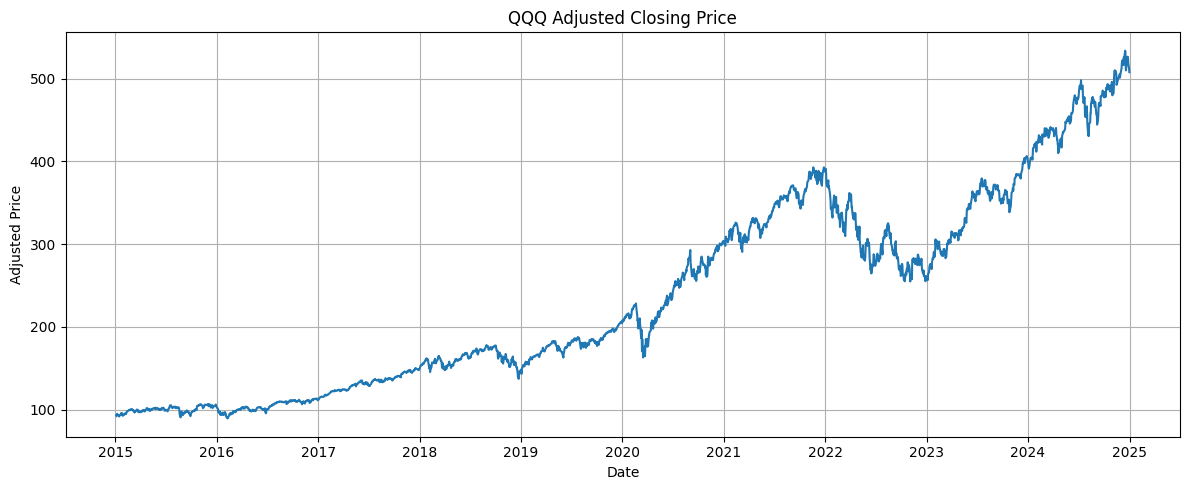

In [16]:
price_fig, price_ax = plot_time_series(df, 'price', f'{ticker} Adjusted Closing Price', 'Adjusted Price')


## Plot log returns


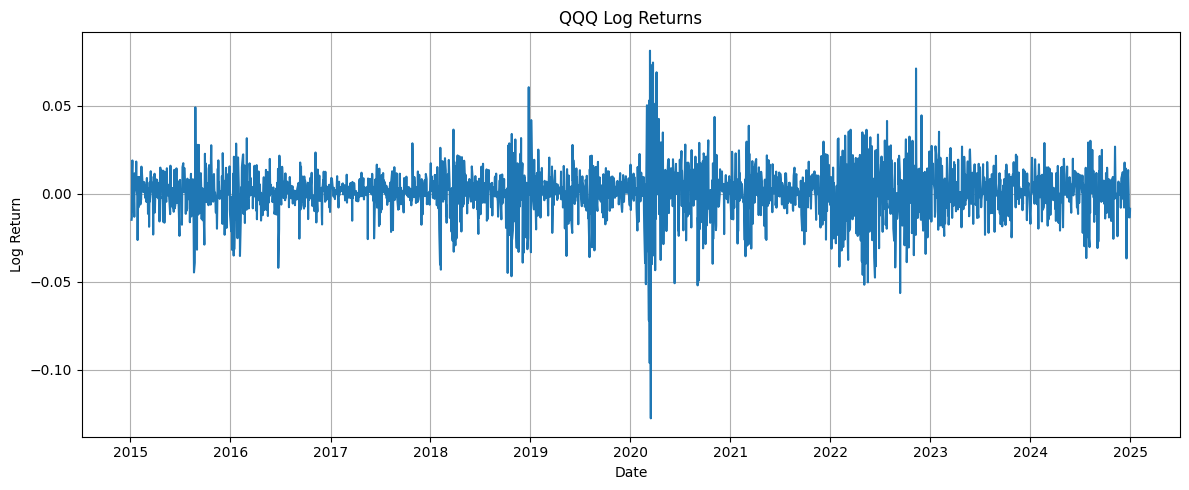

In [17]:
log_return_fig, log_return_ax = plot_time_series(df, 'log_return', f'{ticker} Log Returns', 'Log Return')


## Plot ACF for log returns


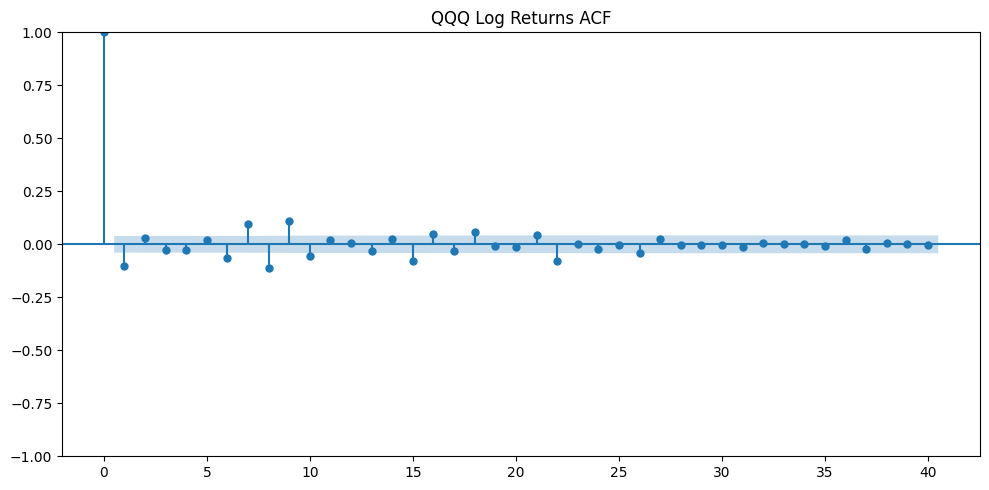

In [18]:
log_return_acf_fig, log_return_acf_ax = plot_acf_inline(df['log_return'], f'{ticker} Log Returns ACF')


## Plot PACF for log returns


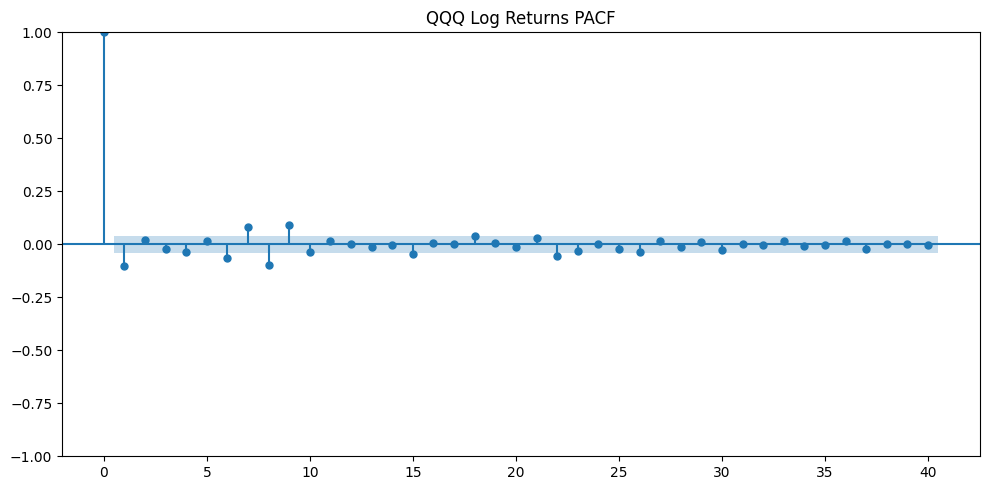

In [19]:
log_return_pacf_fig, log_return_pacf_ax = plot_pacf_inline(df['log_return'], f'{ticker} Log Returns PACF')


## Plot squared returns


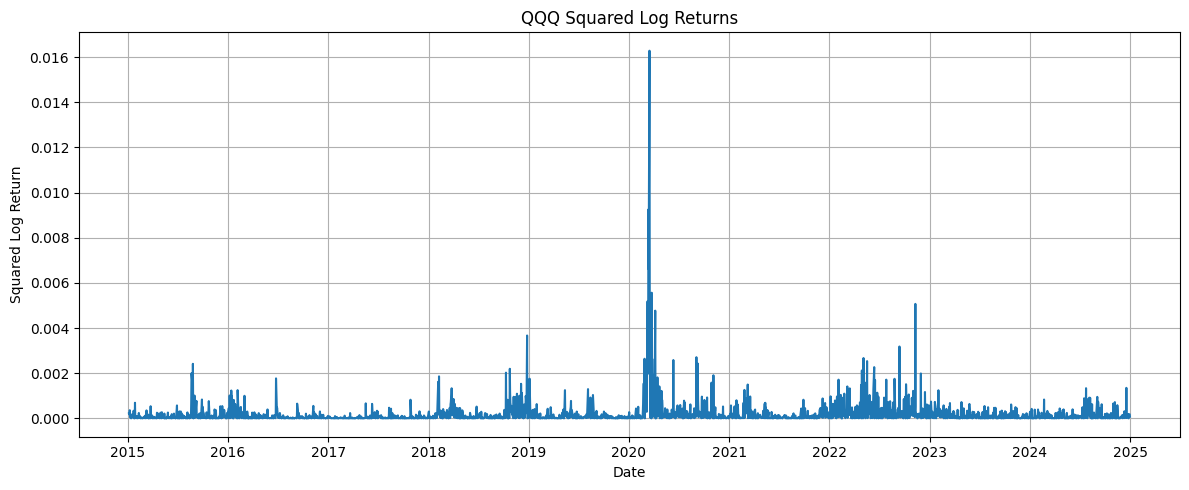

In [20]:
squared_return_fig, squared_return_ax = plot_time_series(df, 'log_return_squared', f'{ticker} Squared Log Returns', 'Squared Log Return')


## Plot ACF for squared returns


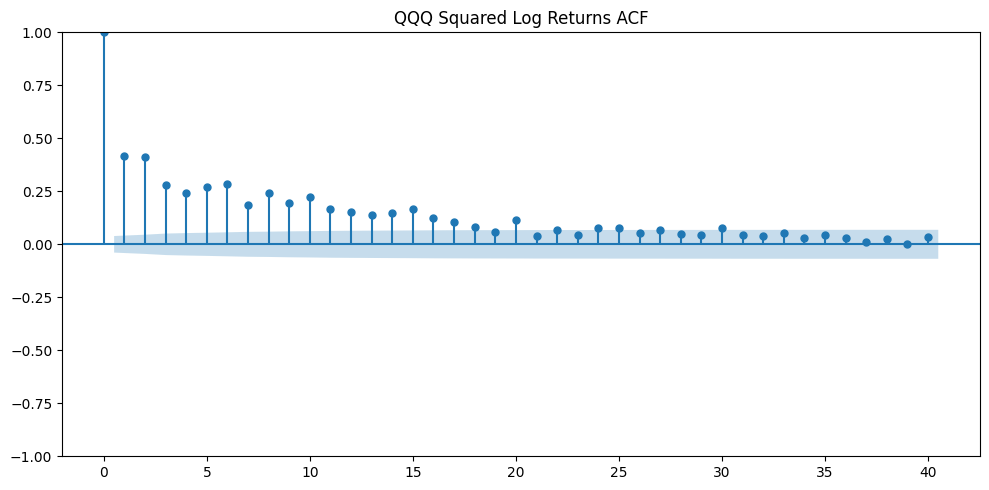

In [21]:
squared_return_acf_fig, squared_return_acf_ax = plot_acf_inline(df['log_return_squared'], f'{ticker} Squared Log Returns ACF')


## Fit GARCH model


In [22]:
df, garch_summary_text = fit_garch_model(df, min_window=500)
print(garch_summary_text if garch_summary_text else 'No GARCH summary available.')


Computing expanding-window GARCH volatility...
Expanding GARCH volatility computed.
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1384.26
Distribution:                  Normal   AIC:                           2776.51
Method:            Maximum Likelihood   BIC:                           2795.25
                                        No. Observations:                  800
Date:                Fri, May 22 2026   Df Residuals:                      799
Time:                        21:40:29   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-------------------------------------------------------

## Plot GARCH volatility


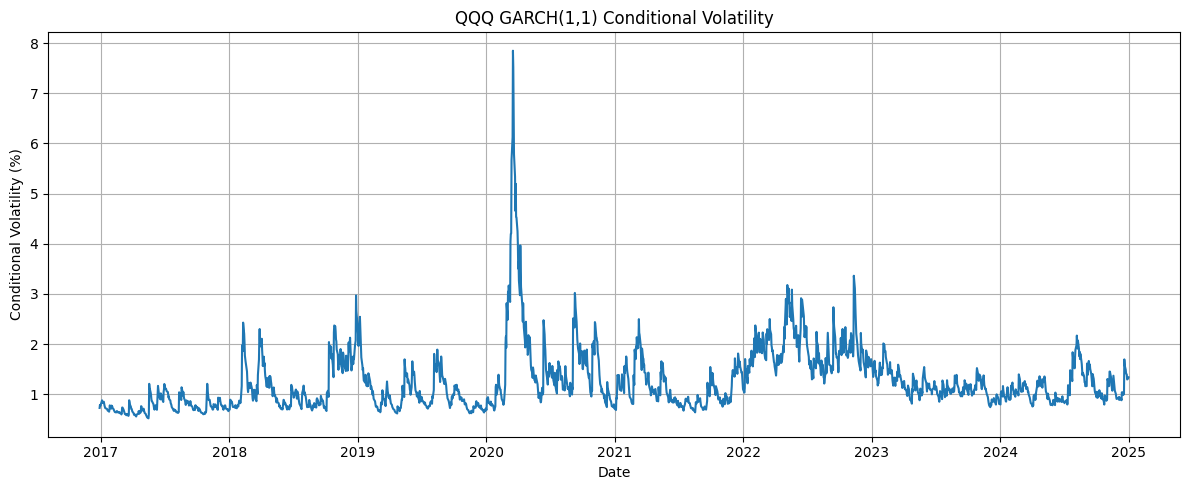

In [23]:
garch_fig, garch_ax = plot_garch_volatility(df, ticker)


## Add market regimes


In [24]:
df = add_market_regimes(df)
display(df[['volatility_regime', 'vix_regime', 'trend_regime', 'market_regime']].tail())


,volatility_regime,vix_regime,trend_regime,market_regime
Date,,,,
2024-12-24,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-26,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-27,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-30,low_vol,normal_vix,uptrend,low_vol_uptrend
2024-12-31,low_vol,normal_vix,uptrend,low_vol_uptrend


## Create LSTM dataset


In [25]:
X_train, X_test, y_train, y_test, test_dates, scaler_preview, feature_cols_preview, model_df_preview = create_lstm_dataset(df, lookback=30)
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)


X_train: (1381, 30, 45)
X_test: (353, 30, 45)
y_train: (1381,)
y_test: (353,)


## Train LSTM


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - accuracy: 0.5553 - loss: 0.6924 - val_accuracy: 0.5126 - val_loss: 0.6929
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5525 - loss: 0.6864 - val_accuracy: 0.5162 - val_loss: 0.6921
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5453 - loss: 0.6826 - val_accuracy: 0.5126 - val_loss: 0.6913
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5679 - loss: 0.6834 - val_accuracy: 0.5054 - val_loss: 0.6934
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5643 - loss: 0.6820 - val_accuracy: 0.5090 - val_loss: 0.6950
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5589 - loss: 0.6827 - val_accuracy: 0.4982 - val_loss: 0.6965
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5553 - loss: 0.6780 - val_accuracy: 0.4946 - val_loss: 0.6963
Epoch 8/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5435 - loss: 0.6786 - val_accuracy: 0.5090 - val_l

,accuracy,baseline_accuracy,roc_auc,prediction_threshold
0,0.410765,0.589235,0.539456,0.55


              precision    recall  f1-score   support

           0       0.41      1.00      0.58       145
           1       0.00      0.00      0.00       208

    accuracy                           0.41       353
   macro avg       0.21      0.50      0.29       353
weighted avg       0.17      0.41      0.24       353

[[145   0]
 [208   0]]


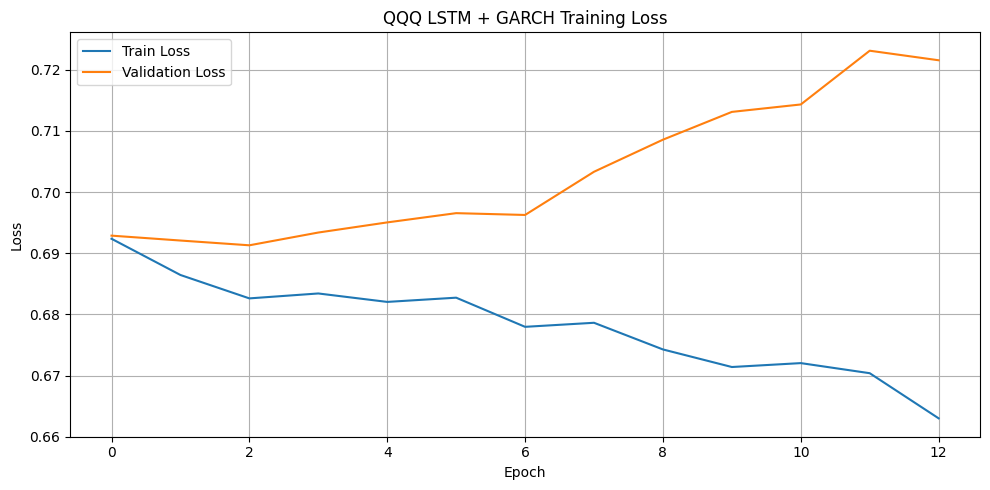

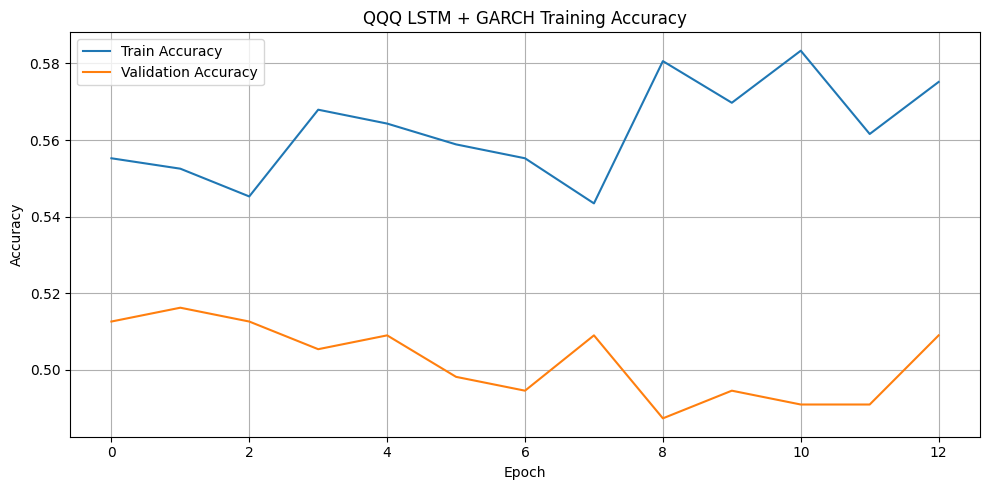

,date,actual_direction,predicted_probability_up,predicted_direction
0,2023-08-08,0,0.483439,0
1,2023-08-09,1,0.481284,0
2,2023-08-10,0,0.483677,0
3,2023-08-11,1,0.486159,0
4,2023-08-14,0,0.487566,0


In [26]:
lstm_model, scaler, feature_cols, predictions_df, history_df, metrics_summary = train_lstm_garch_model(
    df=df,
    ticker=ticker,
    lookback=30,
    epochs=100,
    batch_size=32,
    prediction_threshold=0.55,
)
display(predictions_df.head())


## Next-day forecast


In [27]:
lstm_forecast_df = forecast_lstm_garch_next_day(
    df=df,
    lstm_model=lstm_model,
    scaler=scaler,
    feature_cols=feature_cols,
    ticker=ticker,
    lookback=30,
    threshold=0.55,
)
display(lstm_forecast_df)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


,ticker,lstm_garch_probability_up,threshold,lstm_garch_predicted_direction
0,QQQ,0.482008,0.55,NO TRADE


## Trade recommendation


In [28]:
lstm_forecast_with_trade_df = add_trade_recommendation_column(
    forecast_df=lstm_forecast_df,
    full_df=df,
    upper_prob=0.53,
    lower_prob=0.47,
    volatility_quantile=0.75,
)
display(lstm_forecast_with_trade_df)


,ticker,lstm_garch_probability_up,threshold,lstm_garch_predicted_direction,trade_recommendation
0,QQQ,0.482008,0.55,NO TRADE,NO TRADE


## Rolling ARIMA forecasts


In [29]:
arima_forecasts = generate_rolling_arima_forecasts(
    df=df,
    prediction_dates=predictions_df['date'],
    order=(1, 0, 1),
)
display(arima_forecasts.head())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

,date,arima_mean_forecast_percent
0,2023-08-08,0.183827
1,2023-08-09,0.174791
2,2023-08-10,0.029357
3,2023-08-11,0.147087
4,2023-08-14,-0.072230


## Regime-aware backtest


,ticker,trade_count,trade_rate,hit_rate_on_trades,strategy_total_return,buy_hold_total_return,annualized_sharpe,max_drawdown,risk_off_days,low_vol_uptrend_days,low_vol_downtrend_days,neutral_days
0,QQQ,16,0.045326,0.5,-0.00541,0.387937,-0.542179,-0.011031,26,232,95,0


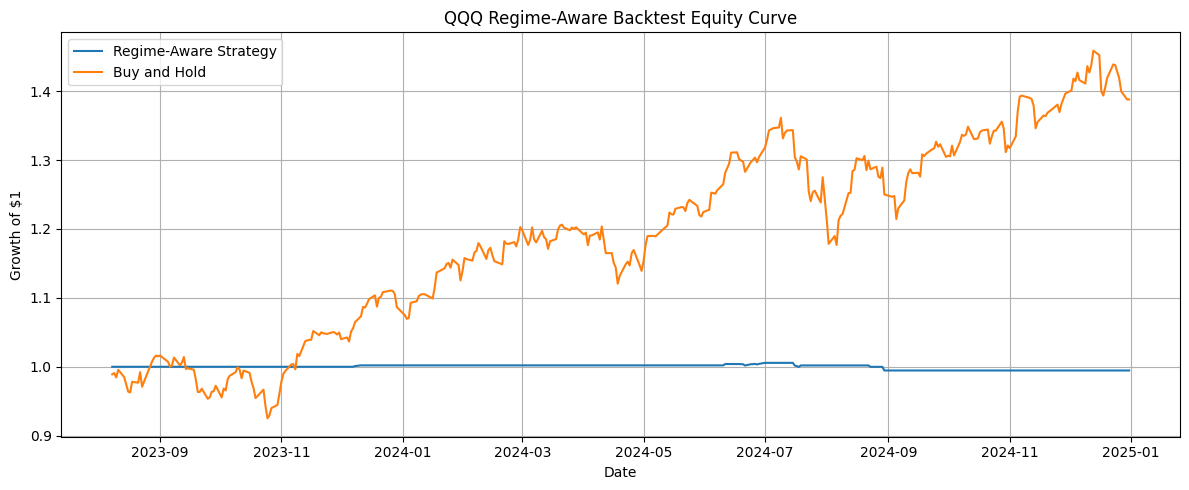

In [30]:
backtest_df, backtest_summary = run_regime_aware_backtest(
    df=df,
    lstm_predictions=predictions_df,
    arima_forecasts=arima_forecasts,
    ticker=ticker,
    upper_prob=0.53,
    lower_prob=0.47,
    signal_threshold=0.03,
    volatility_quantile=0.75,
)
